In [94]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import os
import seaborn as sns
import sys
import glob
import tqdm
plt.style.use('default')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 22, 'legend.facecolor': 'white', 'legend.framealpha': 1, "legend.frameon": 1, "lines.linewidth": 2})

In [95]:
label_df = pd.read_pickle("/extdata4/baeklab/Hyeonseo/m6A/runs/exp_MRNA/ON0090/ON0090/label/v2Genomic.GP3.depth5_None.twm6astrict.pkl")
label_df = label_df[["genome_id", "id", "depth", "label", "m6A_level", "5mer", "drach"]]
label_df.rename(columns = {"genome_id": "label_id","id": "transcript_id","m6A_level": "dom_label"}, inplace = True)
label_df.reset_index(inplace=True)

In [96]:
label_df_filtered = label_df[((label_df["dom_label"] > 0.0) & (label_df["label"] == 1)) | (label_df["label"] == 0)]
label_df_filtered = label_df_filtered[["label_id", "label", "dom_label", "drach"]]
label_df_filtered = label_df_filtered.groupby("label_id").agg({"label": "first", "dom_label": "first", "drach": "max"}).reset_index()
print(label_df_filtered)
print(label_df_filtered["label"].value_counts())
print(len(label_df_filtered["label_id"].unique()))

                label_id  label  dom_label  drach
0        chr10:+:1000681      0        0.0  False
1        chr10:+:1000683      0        0.0   True
2        chr10:+:1000685      0        0.0  False
3        chr10:+:1000701      0        0.0   True
4        chr10:+:1000704      0        0.0  False
...                  ...    ...        ...    ...
7880023  chrX:-:86047509      0        0.0  False
7880024  chrX:-:86047522      0        0.0  False
7880025  chrX:-:86047524      0        0.0  False
7880026  chrX:-:86047533      0        0.0  False
7880027  chrX:-:86047534      0        0.0  False

[7880028 rows x 4 columns]
label
0    7842600
1      37428
Name: count, dtype: int64
7880028


In [97]:
dorado_df = pd.read_pickle("/extdata4/baeklab/Hyeonseo/m6A/runs/exp_MRNA/ON0090/ON0090/result/dorado-070-aligned/intermediates/dorado_output.pkl.m6A.genomic.pkl").reset_index(drop=True)
dorado_df.rename(columns = {"genome_id": "label_id", "count_dom": "dorado_count", "dom": "pred_dorado"}, inplace = True)
dorado_df = dorado_df[dorado_df["dorado_count"] >= 20]
dorado_df = dorado_df.merge(label_df_filtered, on="label_id", how="inner")
dorado_df = dorado_df[["pred_dorado", "dorado_count", "label_id"]]

In [98]:
logsum_df = "/extdata4/baeklab/Hyeonseo/m6A/inference/inference/AIRNA-DW-v4-20240905-092858-10-177000-token_normalise_dwell_bq_npz_allmotif_pileup_psum/pileup.npz.genomic.pkl"
logsum_df = pd.read_pickle(logsum_df).reset_index(drop=True)
logsum_df = logsum_df[logsum_df["count_dom"] >= 20]
logsum_df.rename(columns = {"genome_id": "label_id"}, inplace = True)
logsum_df = logsum_df.merge(label_df_filtered, on="label_id", how="inner")
logsum_df = logsum_df.merge(dorado_df, on="label_id", how="inner")
print(logsum_df)
print(len(logsum_df["label_id"].unique()))

                label_id gene_symbol  coding       dom  count_dom  \
0        chr10:+:1000681      GTPBP4    True  0.008403        476   
1        chr10:+:1000683      GTPBP4    True  0.014463        484   
2        chr10:+:1000685      GTPBP4    True  0.023404        470   
3        chr10:+:1000701      GTPBP4    True  0.012474        481   
4        chr10:+:1000704      GTPBP4    True  0.027027        481   
...                  ...         ...     ...       ...        ...   
6686454  chrX:-:86027546         CHM    True  0.000000         21   
6686455  chrX:-:86027547         CHM    True  0.000000         21   
6686456  chrX:-:86047486         CHM    True  0.000000         20   
6686457  chrX:-:86047498         CHM    True  0.000000         21   
6686458  chrX:-:86047509         CHM    True  0.000000         20   

         logsum_1_p_pos  logsum_1_p_neg  count_neg  count_all  count_pos  \
0             -2.268124       -0.594195        467        482          1   
1              0.00

In [99]:

logsum_df["pm6a_neg"] =  1-10**((logsum_df["logsum_1_p_pos"]+logsum_df["logsum_1_p_neg"])/np.clip(logsum_df["count_pos"]+logsum_df["count_neg"],1,None))
logsum_df["threshold"] = 1-((0.9 ** (1-logsum_df["dom"])) * (0.02 ** (logsum_df["dom"])))
logsum_df["pm6a_neg_thr"] = logsum_df["pm6a_neg"] * (logsum_df["pm6a_neg"] > logsum_df["threshold"])
logsum_df["pm6a_pos"] = -(logsum_df["logsum_1_p_pos"]/np.clip(logsum_df["count_all"],1,None))
logsum_df["pm6a_pos_dom_v2"] =  -(2-logsum_df["dom"])*logsum_df["logsum_1_p_pos"]/logsum_df["count_all"] + ((1-logsum_df["dom"])*np.log10(np.clip(1-logsum_df["dom"],1e-30,1)) + logsum_df["dom"] * np.log10(np.clip(logsum_df["dom"],1e-30,1)))*(logsum_df["count_pos"]/logsum_df["count_all"])

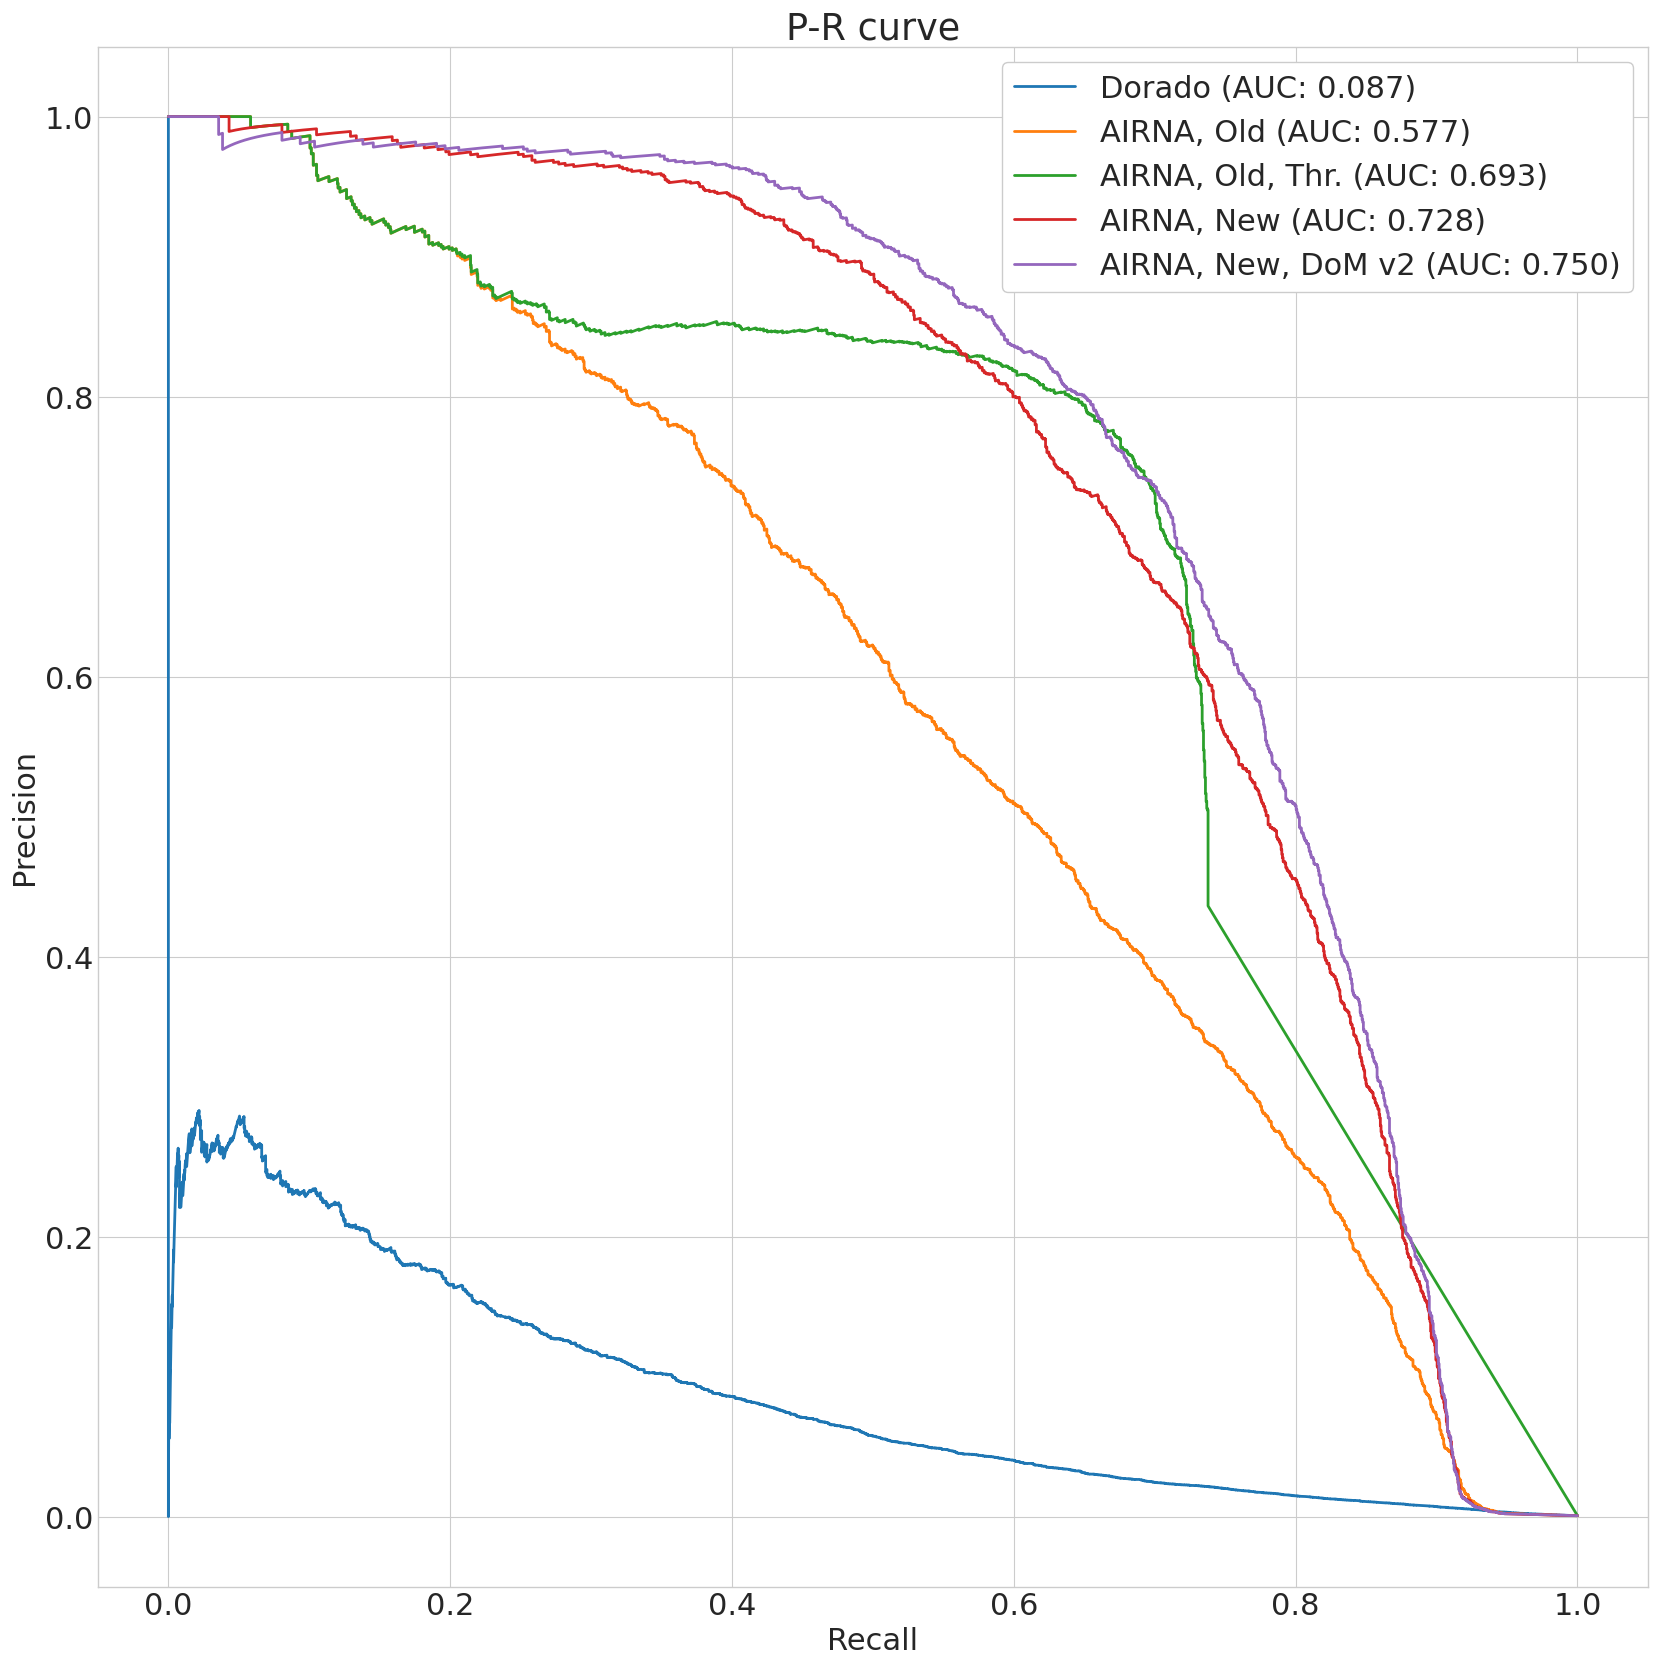

In [58]:
from sklearn.metrics import precision_recall_curve, auc

selected_df = logsum_df[(~logsum_df["drach"]) & (logsum_df["count_dom"] >= 100) & (logsum_df["dorado_count"] >= 100) & ((logsum_df["label"] == 0)|(logsum_df["dom_label"] > 0.1))]

plt.style.use('default')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 22, 'legend.facecolor': 'white', 'legend.framealpha': 1, "legend.frameon": 1, "lines.linewidth": 2})
fig, ax = plt.subplots(1, 1, figsize=(20, 20))

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pred_dorado"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Dorado (AUC: {auc_score:.3f})")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_neg"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"AIRNA, Old (AUC: {auc_score:.3f})")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_neg_thr"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"AIRNA, Old, Thr. (AUC: {auc_score:.3f})")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_pos"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"AIRNA, New (AUC: {auc_score:.3f})")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_pos_dom_v2"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"AIRNA, New, DoM v2 (AUC: {auc_score:.3f})")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("P-R curve")
ax.legend(loc="upper right")
plt.show()

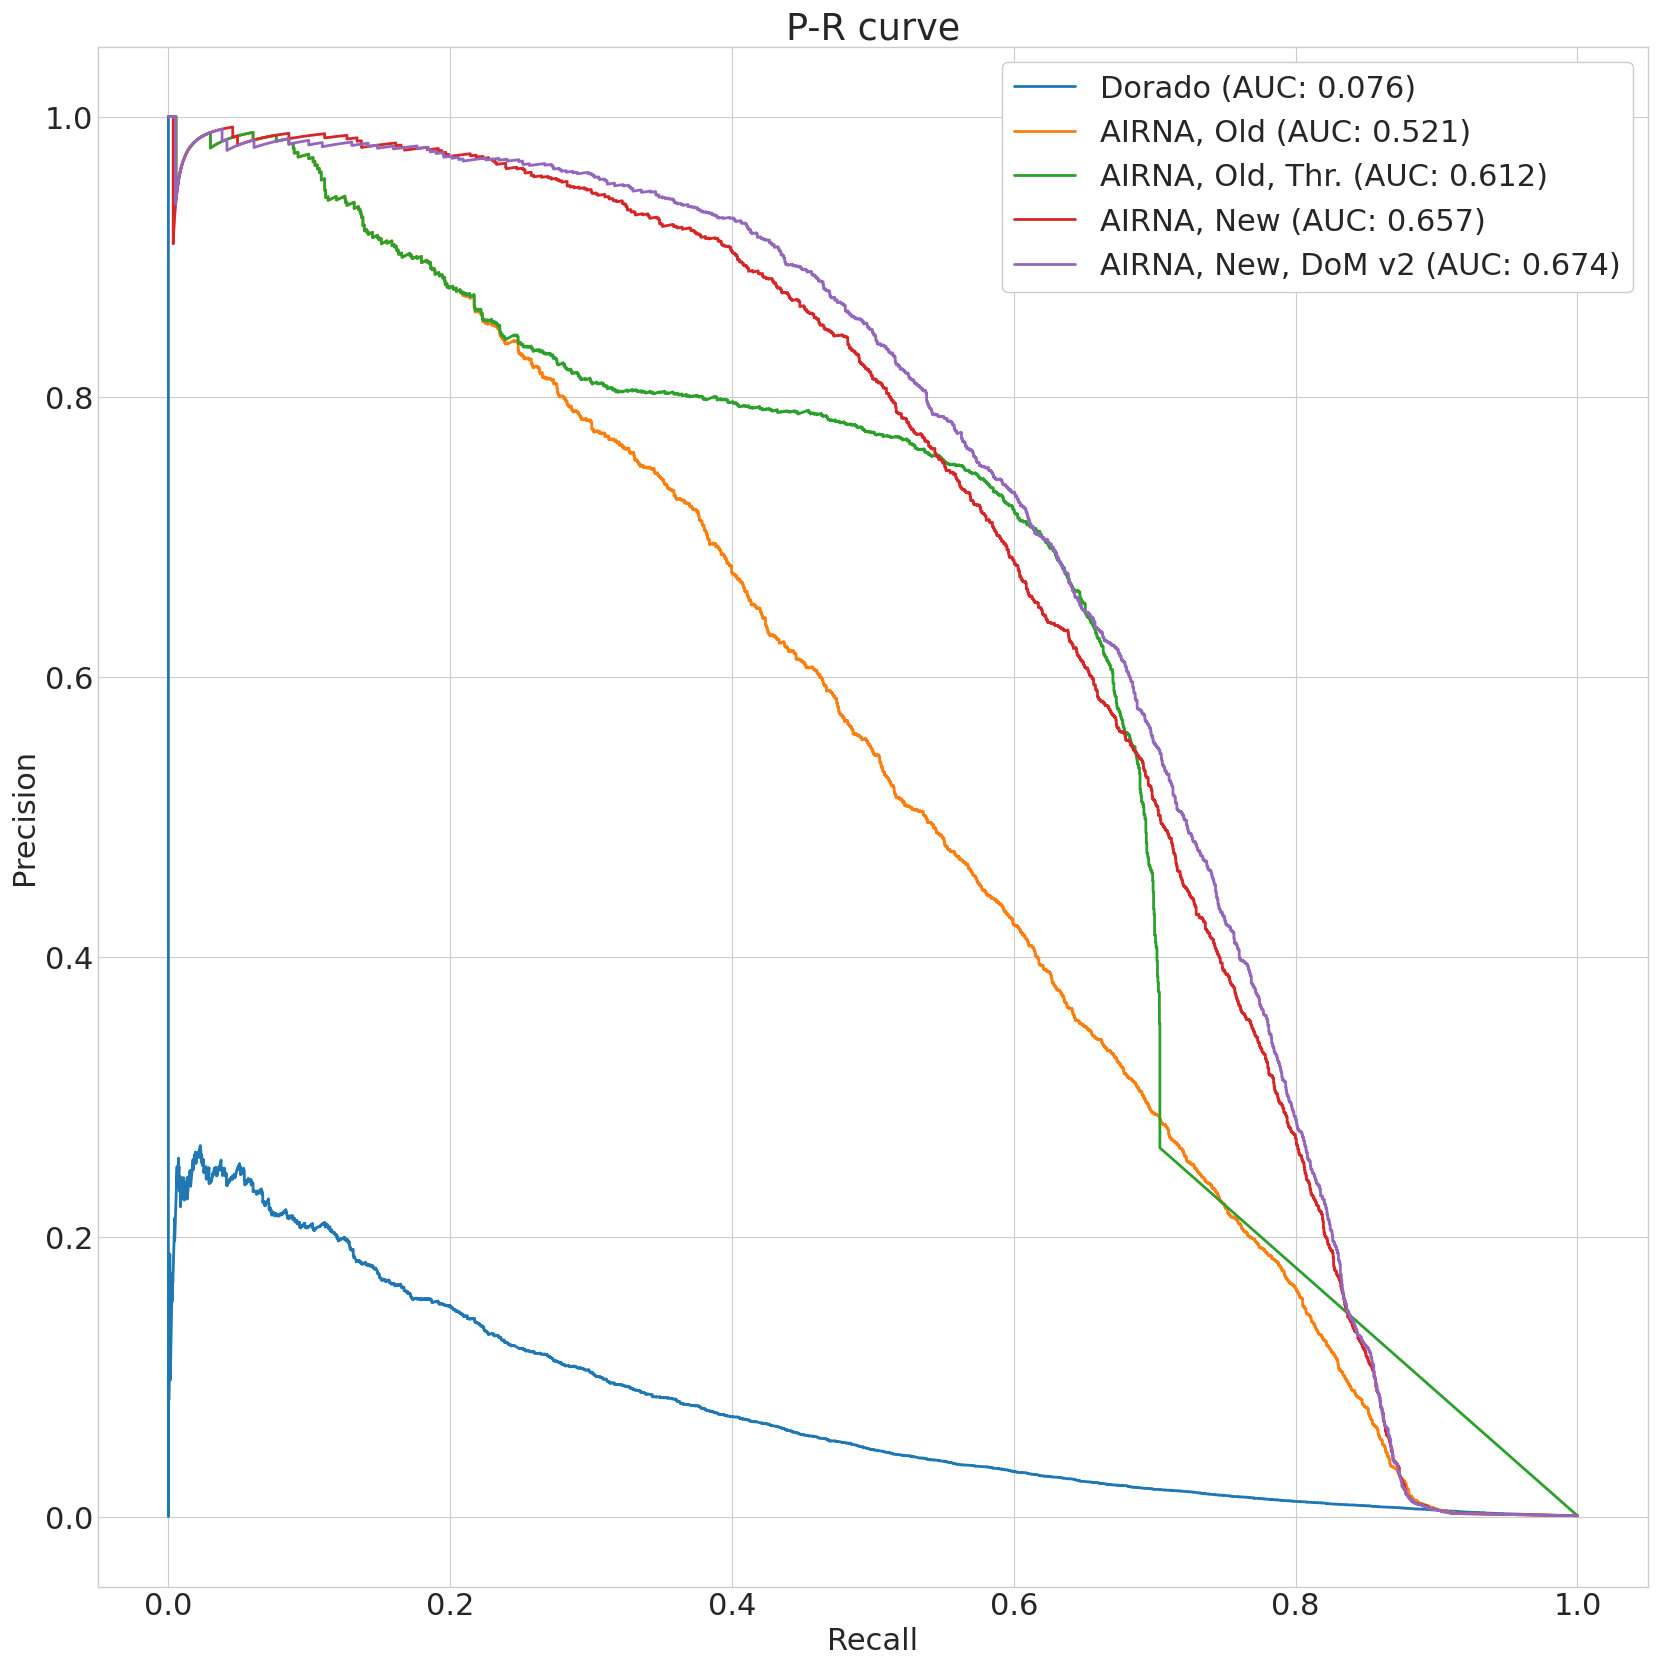

In [59]:
from sklearn.metrics import precision_recall_curve, auc

selected_df = logsum_df[(~logsum_df["drach"]) & (logsum_df["count_dom"] >= 50) & (logsum_df["dorado_count"] >= 50) & (logsum_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]

plt.style.use('default')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 22, 'legend.facecolor': 'white', 'legend.framealpha': 1, "legend.frameon": 1, "lines.linewidth": 2})
fig, ax = plt.subplots(1, 1, figsize=(20, 20))

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pred_dorado"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Dorado (AUC: {auc_score:.3f})")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_neg"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"AIRNA, Old (AUC: {auc_score:.3f})")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_neg_thr"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"AIRNA, Old, Thr. (AUC: {auc_score:.3f})")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_pos"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"AIRNA, New (AUC: {auc_score:.3f})")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_pos_dom_v2"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"AIRNA, New, DoM v2 (AUC: {auc_score:.3f})")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("P-R curve")
ax.legend(loc="upper right")
plt.show()

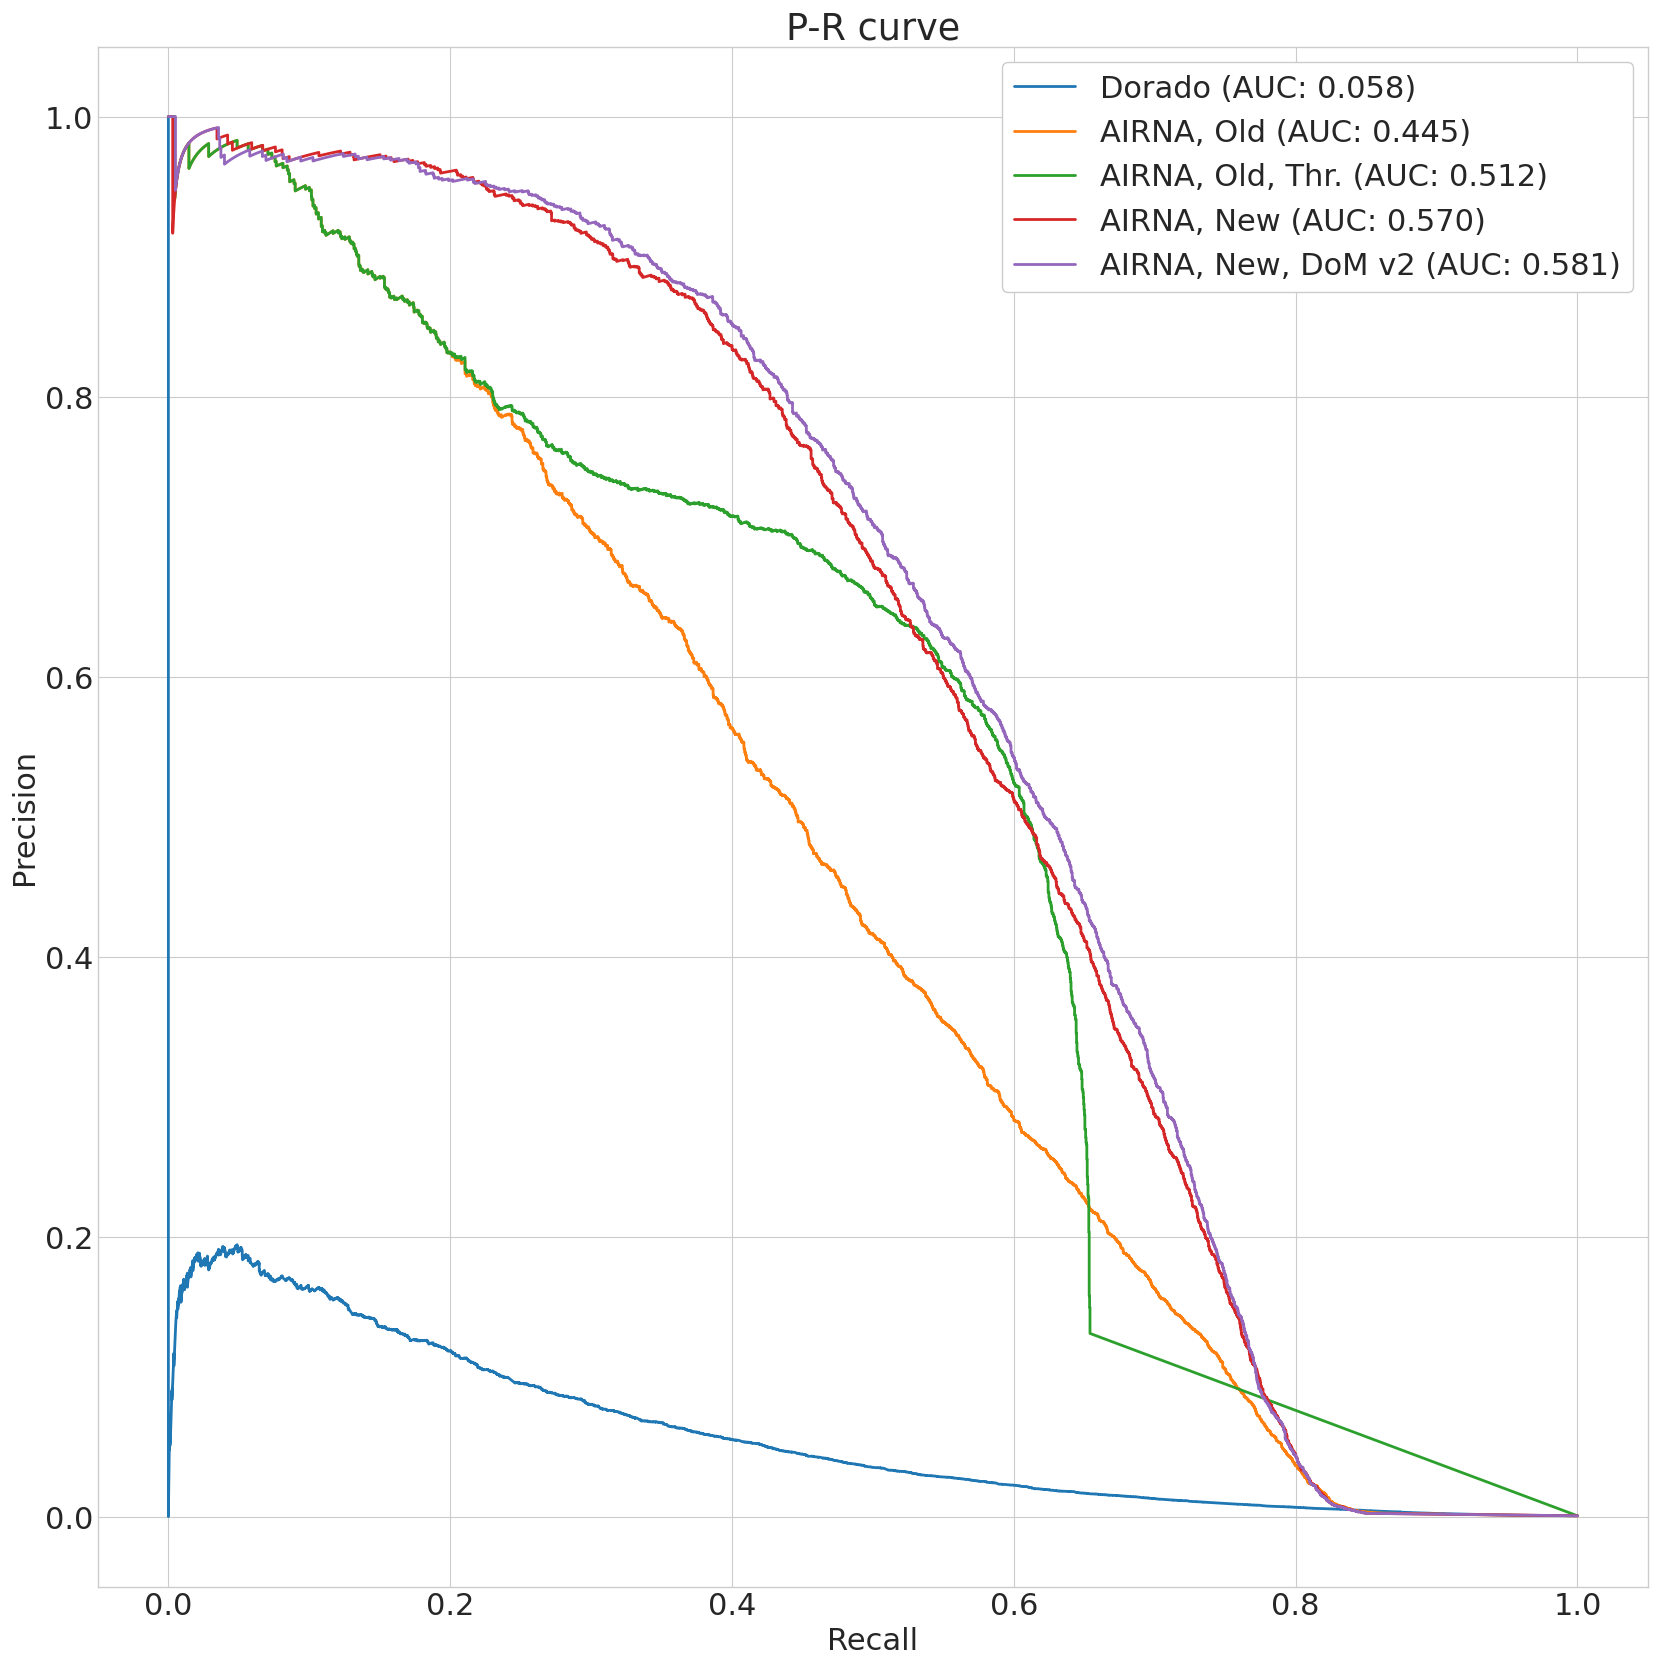

In [60]:
from sklearn.metrics import precision_recall_curve, auc

selected_df = logsum_df[(~logsum_df["drach"]) & (logsum_df["count_dom"] >= 20) & (logsum_df["dorado_count"] >= 20) & (logsum_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]

plt.style.use('default')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 22, 'legend.facecolor': 'white', 'legend.framealpha': 1, "legend.frameon": 1, "lines.linewidth": 2})
fig, ax = plt.subplots(1, 1, figsize=(20, 20))

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pred_dorado"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Dorado (AUC: {auc_score:.3f})")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_neg"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"AIRNA, Old (AUC: {auc_score:.3f})")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_neg_thr"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"AIRNA, Old, Thr. (AUC: {auc_score:.3f})")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_pos"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"AIRNA, New (AUC: {auc_score:.3f})")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_pos_dom_v2"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"AIRNA, New, DoM v2 (AUC: {auc_score:.3f})")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("P-R curve")
ax.legend(loc="upper right")
plt.show()

In [100]:
selected_df = logsum_df[(~logsum_df["drach"]) & (logsum_df["count_dom"] >= 100) & (logsum_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df["pm6a_pos_dom_v2"] =  -(2-selected_df["dom"])*selected_df["logsum_1_p_pos"]/selected_df["count_all"] + ((1-selected_df["dom"])*np.log10(np.clip(1-selected_df["dom"],1e-30,1)) + selected_df["dom"] * np.log10(np.clip(selected_df["dom"],1e-30,1)))*(selected_df["count_pos"]/selected_df["count_all"])


gt_df = selected_df[(selected_df["label"]==1)].copy()
fn_df = gt_df[gt_df["pm6a_pos_dom_v2"] <= 0.1].copy()
tp_df = gt_df[gt_df["pm6a_pos_dom_v2"] > 1.0].copy()


In [64]:
fn_df

,label_id,gene_symbol,coding,dom,count_dom,logsum_1_p_pos,logsum_1_p_neg,count_neg,count_all,count_pos,label,dom_label,drach,pred_dorado,dorado_count,pm6a_neg,threshold,pm6a_neg_thr,pm6a_pos,pm6a_pos_dom_v2
15425,chr10:+:102644714,TRIM8,True,0.077295,207,-9.248193,-0.640934,176,224,3,1,0.106325,False,0.045226,199,0.119451,0.329409,0.0,0.041287,0.077799
25674,chr10:+:104254900,GSTO1,True,0.014706,272,0.000000,-0.605706,259,288,0,1,0.169729,False,0.155673,379,0.005370,0.148998,0.0,-0.000000,-0.000000
134154,chr10:+:84139561,GHITM,True,0.005168,774,0.000000,-0.531176,762,784,0,1,0.163554,False,0.010576,851,0.001604,0.117532,0.0,-0.000000,-0.000000
168212,chr10:-:100185968,ERLIN1,True,0.007692,130,0.000000,-0.295278,125,133,0,1,0.288975,False,0.020690,145,0.005424,0.125972,0.0,-0.000000,-0.000000
278818,chr10:-:71851248,PSAP,True,0.044006,1318,-6.924159,-8.777002,1167,1460,3,1,0.127081,False,0.033435,1316,0.030428,0.238813,0.0,0.004743,0.009115
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6509770,chrX:+:134460191,HPRT1,True,0.006494,154,0.000000,-0.757488,148,159,0,1,0.115196,False,0.000000,156,0.011716,0.121974,0.0,-0.000000,-0.000000
6554149,chrX:+:47218711,CDK16,True,0.165138,109,-2.598554,-0.997499,76,118,1,1,0.179094,False,0.142857,112,0.101955,0.520007,0.0,0.022022,0.038758
6636351,chrX:-:16870331,RBBP7,True,0.047393,211,0.000000,-1.468040,185,239,0,1,0.117640,False,0.008621,232,0.018106,0.248565,0.0,-0.000000,-0.000000
6654457,chrX:-:47144691,NDUFB11,True,0.072607,606,-5.592502,-3.597483,515,690,3,1,0.119322,False,0.015559,707,0.040028,0.317336,0.0,0.008105,0.015130


In [67]:
glori_df = pd.read_csv("/extdata3/baeklab/Hyeonseo/m6A/res/m6asites/glori_m6a.tsv", sep="\t")
glori_df["label_id"] = glori_df["Chr"] + ":" + glori_df["Strand"] + ":" + (glori_df["Sites"]-1).astype(str)

In [68]:
glori_df

,Chr,Sites,Strand,Gene,AGCov_rep1,AGCov_rep2,m6A_level_rep1,m6A_level_rep2,Cluster_info,label_id
0,chr10,47499,-,TUBB8,76,65,0.30263,0.24615,Non-cluster,chr10:-:47498
1,chr10,3835789,+,ELSE,33,31,0.69697,0.58065,Non-cluster,chr10:+:3835788
2,chr10,3899385,+,ELSE,60,57,0.91667,0.89474,Non-cluster,chr10:+:3899384
3,chr10,5357066,+,ELSE,65,53,0.98462,0.94340,Non-cluster,chr10:+:5357065
4,chr10,7596572,+,ELSE,28,30,0.39286,0.23333,Non-cluster,chr10:+:7596571
...,...,...,...,...,...,...,...,...,...,...
170235,chrY,25307890,+,RPL41P6,27,33,0.70370,0.63636,Non-cluster,chrY:+:25307889
170236,chrY,25307971,+,RPL41P6,87,92,0.19540,0.18478,Non-cluster,chrY:+:25307970
170237,chrY,25308031,+,RPL41P6,36,38,0.66667,0.57895,Non-cluster,chrY:+:25308030
170238,chrY,25393262,-,LINC00265-3P,29,19,0.27586,0.52632,Non-cluster,chrY:-:25393261


In [69]:
fn_df["isin_glori"] = fn_df["label_id"].isin(glori_df["label_id"])

In [71]:
fn_df["isin_glori"].value_counts()

isin_glori
False    123
True      79
Name: count, dtype: int64

In [82]:
tp_df["isin_glori"] = tp_df["label_id"].isin(glori_df["label_id"])
tp_df["isin_glori"].value_counts()

isin_glori
True     961
False     39
Name: count, dtype: int64

In [92]:
contingency_table = np.array([[961, 79],[39,123]]).T
print(contingency_table)

[[961  39]
 [ 79 123]]


In [93]:
from scipy import stats
stats.fisher_exact(contingency_table, alternative="greater")

SignificanceResult(statistic=38.365141187926, pvalue=8.485372640194133e-78)